In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Initialize Spark session for crime type analysis
spark = SparkSession.builder \
    .appName("CrimeTypesAnalysis") \
    .master("spark://spark-master:7077") \
    .getOrCreate()

print("Spark initialized.")

Spark initialized.


In [3]:
# Load cleaned dataset
df = spark.read.parquet("hdfs://namenode:9000/data/processed/chicago_crimes_clean.parquet")
print("Loaded records:", df.count())
print(df.columns)

Loaded records: 8422096
['ID', 'Case Number', 'Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'Latitude', 'Longitude', 'crime_datetime', 'crime_year', 'crime_month', 'crime_day', 'crime_hour', 'crime_day_of_week', 'time_of_day', 'season', 'location_category', 'location_risk_weight', 'crime_category', 'crime_severity_level', 'crime_severity_weight', 'is_violent', 'is_night', 'was_arrest_made', 'is_domestic_incident', 'is_public_space', 'risk_score', 'Year']


In [4]:
# --------------------------------------------
# Group by Primary Type (crime category)
# Count occurrences for each crime type
# --------------------------------------------
crime_types = (
    df.groupBy("Primary Type")
      .agg(count("*").alias("crime_count"))
      .orderBy(desc("crime_count"))   # Sort by frequency (descending)
      .toPandas()                     # Convert to Pandas for visualization
)

# Inspect most frequent crime types
print(crime_types.head())

      Primary Type  crime_count
0            THEFT      1787724
1          BATTERY      1534656
2  CRIMINAL DAMAGE       957771
3        NARCOTICS       763699
4          ASSAULT       564237


Saved: crime_types.png


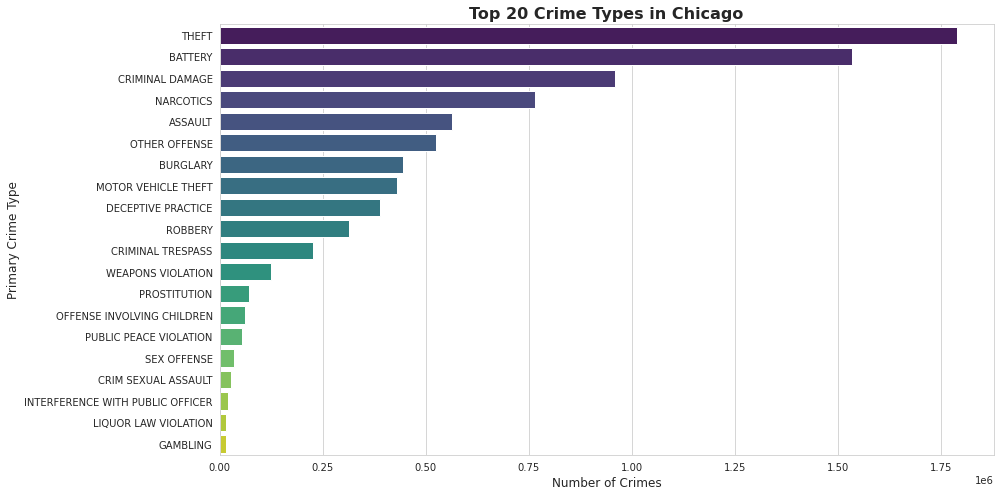

In [5]:
plt.figure(figsize=(14, 7))

# Horizontal bar chart for top 20 crime types
sns.barplot(
    data=crime_types.head(20),
    x="crime_count",
    y="Primary Type",
    palette="viridis"
)

plt.xlabel("Number of Crimes", fontsize=12)
plt.ylabel("Primary Crime Type", fontsize=12)
plt.title(
    "Top 20 Crime Types in Chicago",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

# Save plot for report
plt.savefig(
    "/home/jovyan/notebooks/outputs/crime_types.png",
    dpi=300
)

print("Saved: crime_types.png")

In [6]:
spark.stop()